# Análise comparativa de modelos
 - Conjunto de dados: Laptop Price
 - Cientistas de dados:
   - Ana Camila Conceição Rezende Silva
   - Everton Correia Silva
   - Lucas Pereira De Oliveira
   - Ítalo Lima Da Silva




---




## Metodologia

Esta seção descreve a base de dados utilizada (`laptop_price`) e as etapas de pré-processamento aplicadas antes da modelagem, incluindo tratamento de dados faltantes, codificação de variáveis qualitativas e normalização de variáveis quantitativas.





In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.dummy import DummyRegressor

from sklearn.model_selection import cross_validate, ShuffleSplit, RandomizedSearchCV


In [ ]:
url = "https://raw.githubusercontent.com/omadson/datasets/main/datasets/laptop_price/laptop_price.csv"
df = pd.read_csv(url, encoding="latin-1")

In [ ]:
# @title Dicionário de dados
df_dict = pd.DataFrame([
   {
        "variavel": "laptop_ID",
        "descricao": "Identificador único do notebook.",
        "tipo": "inútil",
        "subtipo": "discreta",
    },
    {
        "variavel": "Company",
        "descricao": "Fabricante do notebook.",
        "tipo": "qualitativa",
        "subtipo": "nominal",
    },
    {
        "variavel": "Product",
        "descricao": "Modelo do notebook.",
        "tipo": "inútil",
        "subtipo": "nominal",
    },
    {
        "variavel": "TypeName",
        "descricao": "Categoria do notebook (Ultrabook, Gaming, Notebook, etc.).",
        "tipo": "qualitativa",
        "subtipo": "nominal",
    },
    {
        "variavel": "Inches",
        "descricao": "Tamanho da tela em polegadas.",
        "tipo": "quantitativa",
        "subtipo": "contínua",
    },
    {
        "variavel": "ScreenResolution",
        "descricao": "Resolução e tecnologia da tela.",
        "tipo": "inútil",
        "subtipo": "nominal",
    },
    {
        "variavel": "Cpu",
        "descricao": "Modelo do processador.",
        "tipo": "qualitativa",
        "subtipo": "nominal",
    },
    {
        "variavel": "Ram",
        "descricao": "Quantidade de memória RAM instalada.",
        "tipo": "quantitativa",
        "subtipo": "discreta",
    },
    {
        "variavel": "Memory",
        "descricao": "Tipo e capacidade do armazenamento.",
        "tipo": "qualitativa",
        "subtipo": "nominal",
    },
    {
        "variavel": "Gpu",
        "descricao": "Modelo da placa de vídeo.",
        "tipo": "qualitativa",
        "subtipo": "nominal",
    },
    {
        "variavel": "OpSys",
        "descricao": "Sistema operacional instalado.",
        "tipo": "qualitativa",
        "subtipo": "nominal",
    },
    {
        "variavel": "Weight",
        "descricao": "Peso do notebook em quilogramas.",
        "tipo": "quantitativa",
        "subtipo": "contínua",
    },
    {
        "variavel": "Price_euros",
        "descricao": "Preço do notebook em euros.",
        "tipo": "quantitativa",
        "subtipo": "contínua",
    },
    {
        "variavel": "Touchscreen",
        "descricao": "Indica se a tela possui tecnologia touchscreen.",
        "tipo": "qualitativa",
        "subtipo": "nominal",
    },
    {
        "variavel": "IPS",
        "descricao": "Indica se a tela utiliza tecnologia IPS.",
        "tipo": "qualitativa",
        "subtipo": "nominal",
    },
    {
        "variavel": "Resolution_X",
        "descricao": "Resolução horizontal da tela em pixels.",
        "tipo": "quantitativa",
        "subtipo": "discreta",
    },
    {
        "variavel": "Resolution_Y",
        "descricao": "Resolução vertical da tela em pixels.",
        "tipo": "quantitativa",
        "subtipo": "discreta",
    },
    {
        "variavel": "PPI",
        "descricao": "Densidade de pixels por polegada da tela.",
        "tipo": "quantitativa",
        "subtipo": "contínua",
    },
])

df_dict

,variavel,descricao,tipo,subtipo
0,laptop_ID,Identificador único do notebook.,inútil,discreta
1,Company,Fabricante do notebook.,qualitativa,nominal
2,Product,Modelo do notebook.,inútil,nominal
3,TypeName,"Categoria do notebook (Ultrabook, Gaming, Note...",qualitativa,nominal
4,Inches,Tamanho da tela em polegadas.,quantitativa,contínua
5,ScreenResolution,Resolução e tecnologia da tela.,inútil,nominal
6,Cpu,Modelo do processador.,qualitativa,nominal
7,Ram,Quantidade de memória RAM instalada.,quantitativa,discreta
8,Memory,Tipo e capacidade do armazenamento.,qualitativa,nominal
9,Gpu,Modelo da placa de vídeo.,qualitativa,nominal


In [ ]:
# aplicando tratamentos da Entrega 1

df["Ram"] = df["Ram"].str.replace("GB", "", regex=False).astype(int)
df["Weight"] = df["Weight"].str.replace("kg", "",  regex=False).astype(float)
df["Touchscreen"] = df["ScreenResolution"].str.contains("Touchscreen", case=False).astype(int)
df["IPS"] = df["ScreenResolution"].str.contains("IPS", case=False).astype(int)
resolucao = df["ScreenResolution"].str.extract(r'(\d+)x(\d+)')
df["Resolution_X"] = resolucao[0].astype(int)
df["Resolution_Y"] = resolucao[1].astype(int)
df["PPI"] = (np.sqrt(df["Resolution_X"]**2 + df["Resolution_Y"]**2) / df["Inches"])

df.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros,Touchscreen,IPS,Resolution_X,Resolution_Y,PPI
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,1339.69,0,1,2560,1600,226.983005
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,898.94,0,0,1440,900,127.677940
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,575.00,0,0,1920,1080,141.211998
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,2537.45,0,1,2880,1800,220.534624
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,1803.60,0,1,2560,1600,226.983005


In [ ]:
# @title Seleção de variáveis e separação de entradas e saídas
target_variable = ['Price_euros']
useless_variables =  (
    df_dict
    .query("tipo == 'inútil'")
    .variavel
    .to_list()
)
unused_variables = useless_variables + target_variable
nominal_variables = (
    df_dict
    .query("subtipo == 'nominal' and variavel not in @unused_variables")
    .variavel
    .to_list()

)
continuous_variables = (
    df_dict
    .query("subtipo == 'contínua' and variavel not in @unused_variables")
    .variavel
    .to_list()
)
discrete_variables = (
    df_dict
    .query("subtipo == 'discreta' and variavel not in @unused_variables")
    .variavel
    .to_list()
)

X = df.drop(columns=unused_variables)
y = df[target_variable]

## Preparação de dados

Cada um dos tipos de variáveis foi submetido a um fluxo de tratamento de dados específico, a saber:

### Variáveis quantitativas
 - **Contínuas**: imputação de valores faltantes através da média e normalização min-max.
 - **Discretas**: imputação de valores faltatnes através da mediana e normalização min-max.

### Variáveis qualitativas
 - **Nominais**: imputação de valores faltantes a partir do valor mais frequente e codificação via *one-hot encoding*.

In [ ]:
# variáveis discretas ( Ram)
discrete_preprocessing = Pipeline(steps=[
    ("missing", SimpleImputer(strategy='median')), # tratamento de dados faltantes
    ("normalization",  MinMaxScaler())# normalização
])
# variáveis contínuas (Price_euros, Inches, Weight, PPI)
continuous_preprocessing = Pipeline(steps=[
    ("missing", SimpleImputer(strategy='mean')), # tratamento de dados faltantes
    ("normalization",  MinMaxScaler())# normalização

])
# variáveis nominais (Company, TypeName, OpSys, Touchscreen, IPS)
nominal_preprocessing = Pipeline(steps=[
    ("missing", SimpleImputer(strategy='most_frequent')), # tratamento de dados faltantes
    ("encoding", OneHotEncoder(sparse_output=False, handle_unknown="ignore")) # codificação de variáveis
])

## Configuração do Experimento

Esta seção detalha os modelos avaliados, a estratégia de validação cruzada escolhida (com a respectiva justificativa) e a busca de hiperparâmetros realizada para cada modelo.

## Validação cruzada

Iremos analisar quatro modelos, que serão testados utilizando a validação cruzada de monte-carlo com 30 repetições. Os modelos utilizados na análise são:

 - Regressão linear (Linear Regression)
 - K-vizinhos mais próximos (K-Nearest-Neighbors)
 - Máquinas de vetores-suporte (Support Vector Machine)
 - Árvores de decisão (Decision Tree)

Além disso, cada um desses algoritmos será testado com diferentes hiper-parametros, para que possamos encontrar o melhor modelo e a melhor configuração possível para esse modelo. Tal otimização será realizada utilizando com um validação cruzada k-fold a partir dos dados de treinamento.

Utilizaremos as seguintes métricas para análise:
 - **Erro médio absoluto (*mean absolute error*, MAE)**: mede o erro médio absoluto entre valores reais e previstos. Tem interpretação direta em unidades da variável alvo.
 - **Erro médio quadrático (*mean squared error*, MSE)**: penaliza mais fortemente os grandes erros (pois eleva ao quadrado).
 - **Coeficiente de determinação (R² score)**: mede quanto o modelo consegue reduzir o erro comparado a média dos dados. Varia entre menos infinito até 1. Um bom modelo tende a ter valores próximos de 1.
 - **Erro percentual médio absoluto (*mean absolute percentage error*, MAPE)**: mede o erro percentual médio. É mais indicado quando temos valores de diferentes escalas.

**Por que Monte Carlo (ShuffleSplit) em vez de K-Fold ou holdout?** Optamos pela validação cruzada de Monte Carlo, com 30 repetições, porque ela permite controlar de forma independente o número de repetições e o tamanho de cada divisão treino/teste, sem a restrição de que cada amostra apareça exatamente uma vez no conjunto de teste (como ocorre no K-Fold). Com 30 repetições, obtemos uma estimativa mais estável da variabilidade do desempenho de cada modelo — o que é especialmente importante aqui, já que a codificação one-hot de `Cpu`, `Memory` e `Gpu` gera um número elevado de colunas em relação ao número de linhas de treino, tornando o desempenho de alguns modelos mais sensível à divisão específica dos dados. Um holdout único poderia mascarar essa instabilidade; o K-Fold, por sua vez, exigiria mais repetições completas do dataset para atingir o mesmo número de estimativas do erro.

In [ ]:
# @title Implementação dos modelos
preprocessing = ColumnTransformer(transformers=[
    ("nominal", nominal_preprocessing, nominal_variables),
    ("discrete", discrete_preprocessing, discrete_variables),
    ("continuous", continuous_preprocessing, continuous_variables),
], remainder='passthrough')

modelos = [
    {
        "nome": "Baseline (Dummy)",
        "objeto": DummyRegressor(),
        "hp": {
            'strategy': ['mean', 'median'] #Teste se é melhor prever usando média ou a medianados preços
        }
    }, {
        "nome": "Regressão Linear",
        "objeto": LinearRegression(), #Utilizando regressão linear padrão como modelo base forte
        "hp": {
            'fit_intercept': [True, False]
        }
    }, {

        "nome": "Árvore de Decisão",
        "objeto": DecisionTreeRegressor(random_state=42),
        "hp": {
            'max_depth': [10, 20, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': ['sqrt', 'log2']
        }
    }, {
        "nome": "KNN",
        "objeto": KNeighborsRegressor(),
        "hp": {
            'n_neighbors': np.arange(3, 15, 2), #Testando números ímpares de vizinhos
            'weights': ['uniform', 'distance'],
            'p': [ 1, 2]
        }
    }, {

        "nome": "SVR",
        "objeto": SVR(),
        "hp": {
        'kernel': ['linear', 'rbf'],
        'C': [0.1, 1, 10],
    }
}

]

In [ ]:
# @title Aplicação da validação cruzada
from sklearn.model_selection import train_test_split
import time

# 1. Separar dados uma única vez
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Tamanho do treino: {X_train.shape[0]} amostras")
print(f"Tamanho do teste: {X_test.shape[0]} amostras")

# 2. Aplicar preprocessing UMA ÚNICA VEZ
print("Aplicando pré-processamento...")
X_train_processed = preprocessing.fit_transform(X_train)
X_test_processed = preprocessing.transform(X_test)
print(f"Dados processados: {X_train_processed.shape}")

# 3. Métricas
metrics = {
    'r2': 'R2',
    'neg_mean_absolute_error': 'MAE',
    'neg_mean_squared_error': 'MSE',
    'neg_mean_absolute_percentage_error': 'MAPE'
}

results = []
best_estimators = {}  # guarda o melhor modelo de cada família, para avaliar no conjunto de teste depois
cv = ShuffleSplit(n_splits=30, test_size=0.2, random_state=42)

print("\nIniciando treinamento dos modelos...")
for modelo in modelos:  # REUTILIZA a lista já definida
    print(f"\n--- {modelo['nome']} ---")
    start_time = time.time()

    # Define número de iterações
    if modelo["nome"] in ["Baseline (Dummy)", "Regressão Linear"]:
        n_iter = 2
    else:
        n_iter = 10  # Reduzido de 10 para 5 se quiser mais rápido

    # Busca de hiperparâmetros (apenas no treino)
    random_search = RandomizedSearchCV(
        estimator=modelo["objeto"],
        param_distributions=modelo["hp"],
        n_iter=n_iter,
        cv=5,
        scoring='neg_mean_squared_error',
        random_state=42,
        n_jobs=-1  # Paralelização
    )

    random_search.fit(X_train_processed, y_train.values.ravel())

    print(f"Melhores parâmetros: {random_search.best_params_}")
    print(f"Melhor score (treino): {random_search.best_score_:.4f}")

    best_estimators[modelo["nome"]] = random_search.best_estimator_

    # Validação cruzada final com o melhor modelo
    metric_results = cross_validate(
        random_search.best_estimator_,
        X_train_processed,
        y_train.values.ravel(),
        cv=cv,
        scoring=list(metrics.keys()),
        n_jobs=-1
    )

    # Adiciona nome do modelo
    metric_results['modelo'] = [modelo["nome"]] * len(metric_results['fit_time'])

    # Converte métricas negativas para positivas
    for metric in metrics.keys():
        if 'neg' in metric:
            metric_results[f"test_{metric}"] *= -1

    results.append(pd.DataFrame(metric_results))

    elapsed = time.time() - start_time
    print(f"Tempo total: {elapsed:.2f} segundos")





Tamanho do treino: 1042 amostras
Tamanho do teste: 261 amostras
Aplicando pré-processamento...
Dados processados: (1042, 285)

Iniciando treinamento dos modelos...

--- Baseline (Dummy) ---
Melhores parâmetros: {'strategy': 'mean'}
Melhor score (treino): -485071.6730
Tempo total: 4.69 segundos

--- Regressão Linear ---
Melhores parâmetros: {'fit_intercept': True}
Melhor score (treino): -99662.6394
Tempo total: 3.25 segundos

--- Árvore de Decisão ---
Melhores parâmetros: {'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}
Melhor score (treino): -158380.5331
Tempo total: 2.65 segundos

--- KNN ---
Melhores parâmetros: {'weights': 'distance', 'p': 1, 'n_neighbors': np.int64(3)}
Melhor score (treino): -100764.2621
Tempo total: 8.27 segundos

--- SVR ---


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Melhores parâmetros: {'kernel': 'linear', 'C': 10}
Melhor score (treino): -180699.9836
Tempo total: 11.58 segundos


## Resultados e Discussão

Esta seção apresenta os resultados da validação cruzada para os quatro modelos avaliados (baseline, regressão linear, árvore de decisão, kNN e SVR) e discute o desempenho de cada um.

In [ ]:
# 4. Resultados finais
final_results = pd.concat(results, axis=0, ignore_index=True)

# Renomeia colunas
final_results_renamed = final_results.rename(columns={
    f"test_{name}": value for name, value in metrics.items()
})

# Mostra resultados
print("\n" + "="*60)
print("RESULTADOS FINAIS")
print("="*60)

# Função highlight (copiada da célula original)
def highlight_best(s, props=''):
    if s.name[1] != 'std':
        if s.name[0].endswith('time'):
            return np.where(s == np.min(s.values), props, '')
        if s.name[0].endswith('R2'):
            return np.where(s == np.max(s.values), props, '')
        return np.where(s == np.min(s.values), props, '')

display(
    final_results_renamed
    .groupby("modelo")
    .agg(["mean", "std"])
    .T
    .style
    .apply(highlight_best, props='color:white;background-color:gray;font-weight: bold;', axis=1)
    .set_table_styles([{'selector': 'td', 'props': 'text-align: center;'}]))



RESULTADOS FINAIS


### Avaliação final no conjunto de teste

Até aqui, os resultados vieram exclusivamente da validação cruzada de Monte Carlo sobre o conjunto de **treino** (usada também para a busca de hiperparâmetros). Para confirmar que o desempenho estimado se generaliza, avaliamos agora o melhor modelo de cada família — já ajustado com os melhores hiperparâmetros encontrados — no conjunto de **teste**, que ficou totalmente fora do processo de treinamento e otimização.

In [ ]:
# @title Avaliação dos melhores modelos no conjunto de teste (held-out)
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

test_eval_rows = []
for nome_modelo, estimator in best_estimators.items():
    y_pred = estimator.predict(X_test_processed)
    test_eval_rows.append({
        "Modelo": nome_modelo,
        "R2": r2_score(y_test, y_pred),
        "MAE": mean_absolute_error(y_test, y_pred),
        "MSE": mean_squared_error(y_test, y_pred),
        "MAPE": mean_absolute_percentage_error(y_test, y_pred),
    })

df_teste = pd.DataFrame(test_eval_rows).sort_values("R2", ascending=False).reset_index(drop=True)
df_teste

,Modelo,R2,MAE,MSE,MAPE
0,Regressão Linear,0.826932,210.932848,87905.581489,0.223489
1,KNN,0.803634,202.939442,99739.354482,0.188421
2,Árvore de Decisão,0.573780,286.849794,216488.256972,0.275154
3,SVR,0.539898,271.695583,233698.232798,0.250312
4,Baseline (Dummy),-0.001065,514.636391,508467.222652,0.680946


### Comparação gráfica dos modelos (validação cruzada)

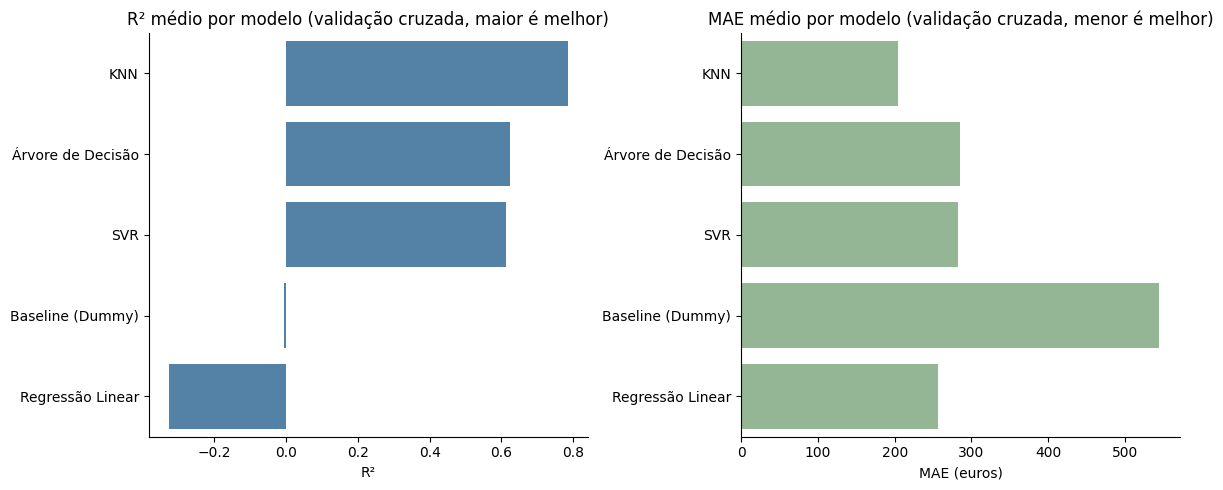

In [ ]:
# @title Comparação gráfica dos modelos
resumo_cv = final_results_renamed.groupby("modelo")[["R2", "MAE"]].mean().reset_index()

fig, axes = plt.subplots(figsize=(12, 5), ncols=2)
ordem = resumo_cv.sort_values("R2", ascending=False)["modelo"]

sns.barplot(data=resumo_cv, x="R2", y="modelo", order=ordem, ax=axes[0], color="steelblue")
axes[0].set(title="R² médio por modelo (validação cruzada, maior é melhor)", xlabel="R²", ylabel="")
for side in ["top", "right"]:
    axes[0].spines[side].set_visible(False)

sns.barplot(data=resumo_cv, x="MAE", y="modelo", order=ordem, ax=axes[1], color="darkseagreen")
axes[1].set(title="MAE médio por modelo (validação cruzada, menor é melhor)", xlabel="MAE (euros)", ylabel="")
for side in ["top", "right"]:
    axes[1].spines[side].set_visible(False)

plt.tight_layout()
plt.show()

## Conclusão

Com base nos resultados gerados pela validação cruzada em nossa base de `Laptop Price`, podemos traçar conclusões importantes sobre o comportamento de cada modelo em prever os preços:

1. **Destaque Positivo (KNN):** O K-Nearest-Neighbors demonstrou o melhor desempenho do projeto, superando os modelos baseados em árvore. Ele obteve o maior coeficiente R² médio (aproximadamente 0.78), além de registrar o menor erro médio absoluto (MAE de ~204) e erro percentual (MAPE de ~17,8%). Isso aponta que agrupar laptops por proximidade de configurações é uma estratégia altamente eficaz neste contexto.
.

2. **Falha da Regressão Linear:** O modelo Linear Regression enfrentou problemas de instabilidade severa nos dados de teste (com um R² negativo médio de -0.32). A conclusão do estudo aponta que isso se dá pelo excesso de multicolinearidade gerado pelo processo de One-Hot Encoding em um cenário sem penalização/regularização.

3. **Desempenho Mediano (SVR e DTR):** O SVR forneceu resultados constantes, porém com uma expressividade inferior (R² de ~0.61) por causa do limite computacional que restringiu a busca exaustiva por parâmetros melhores. A Árvore de Decisão entregou métricas semelhantes (R² de ~0.62).


**Passos Futuros:** A análise orienta que as próximas iterações devem focar em utilizar algoritmos de vizinhança/ensemble ou aplicar regularização (Ridge ou Lasso) caso modelos de regressão linear ainda precisem ser utilizados com as variáveis categóricas espalhadas.